## Titanic Survival Prediction

This project focuses on predicting passenger survival from the sinking of the Titanic using a Random Forest Classifier. The workflow begins with a thorough preprocessing of the dataset from OpenML, which includes handling missing values through imputation and removal, encoding categorical features, and exploratory data analysis to understand feature correlations. An initial Random Forest model achieved an accuracy of 78%. To optimize performance, RandomizedSearchCV was employed for hyperparameter tuning, which improved the model's final accuracy to 84%. The model's effectiveness was further validated using a confusion matrix, ROC/AUC curve, and feature importance analysis, which identified passenger sex, fare, and age as the most significant predictors of survival.

In [ ]:
##Import necessary libraries
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
# data loading
titanic = fetch_openml("titanic", version=1, as_frame=True)
X = titanic.data
y = titanic.target

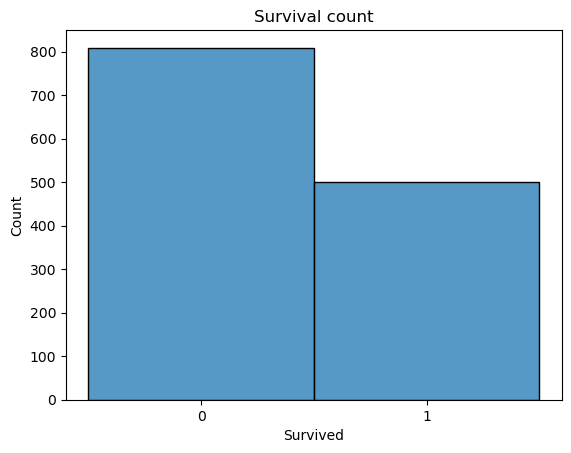

In [3]:
# data visualization
sns.histplot(y, kde=False)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Survival count")
plt.show()

In [4]:
X

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [5]:
columns_list = X.columns.tolist()
print(columns_list)

['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']


Preprocessing phase

1.Missing value

In [6]:
missing_percentage = (X.isnull().mean() * 100).round(2)
print(missing_percentage)

pclass        0.00
name          0.00
sex           0.00
age          20.09
sibsp         0.00
parch         0.00
ticket        0.00
fare          0.08
cabin        77.46
embarked      0.15
boat         62.87
body         90.76
home.dest    43.09
dtype: float64


cabin , boat , body have a lot of missing value so i will delete them

In [7]:
X = X.drop(columns=['body', 'cabin', 'boat'])

In [8]:
X["home.dest"].unique()

array(['St Louis, MO', 'Montreal, PQ / Chesterville, ON', 'New York, NY',
       'Hudson, NY', 'Belfast, NI', 'Bayside, Queens, NY',
       'Montevideo, Uruguay', 'Paris, France', nan, 'Hessle, Yorks',
       'Montreal, PQ', 'Winnipeg, MN', 'San Francisco, CA',
       'Dowagiac, MI', 'Stockholm, Sweden / Washington, DC',
       'Trenton, NJ', 'Glen Ridge, NJ', 'Youngstown, OH',
       'Birkdale, England Cleveland, Ohio', 'London / Winnipeg, MB',
       'Cooperstown, NY', 'St Leonards-on-Sea, England Ohio',
       'Los Angeles, CA', 'Pomeroy, WA', 'Omaha, NE', 'Philadelphia, PA',
       'Denver, CO', 'Belmont, MA', 'Washington, DC',
       'Austria-Hungary / Germantown, Philadelphia, PA',
       'Germantown, Philadelphia, PA', 'Bryn Mawr, PA',
       'Ascot, Berkshire / Rochester, NY', 'Little Onn Hall, Staffs',
       'Amenia, ND', 'New York, NY / Ithaca, NY', 'London, England',
       'Liverpool, England / Belfast', 'Stoughton, MA', 'Victoria, BC',
       'Lakewood, NJ', 'Roachdale, I

In [9]:
num_unique = X["home.dest"].nunique()  # Excludes NaN by default
print(f"Number of unique values (excluding NaN): {num_unique}")

Number of unique values (excluding NaN): 369


In [10]:
X["home.dest"].value_counts()

home.dest
New York, NY                                    64
London                                          14
Montreal, PQ                                    10
Paris, France                                    9
Cornwall / Akron, OH                             9
                                                ..
Chelsea, London                                  1
Harrow-on-the-Hill, Middlesex                    1
Copenhagen, Denmark                              1
Guernsey / Montclair, NJ and/or Toledo, Ohio     1
Antwerp, Belgium / Stanton, OH                   1
Name: count, Length: 369, dtype: int64

In [11]:
X = X.drop(columns=['home.dest'])

In [12]:
X.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S


In [13]:
y.head()

0    1
1    1
2    0
3    0
4    0
Name: survived, dtype: category
Categories (2, object): ['0', '1']

In [14]:
missing_percentage = (X.isnull().mean() * 100).round(2)
print(missing_percentage)

pclass       0.00
name         0.00
sex          0.00
age         20.09
sibsp        0.00
parch        0.00
ticket       0.00
fare         0.08
embarked     0.15
dtype: float64


In [15]:
X["age"].value_counts()

age
24.0000    47
22.0000    43
21.0000    41
30.0000    40
18.0000    39
           ..
0.3333      1
22.5000     1
70.5000     1
0.6667      1
26.5000     1
Name: count, Length: 98, dtype: int64

In [17]:
np.mean(X["age"])

29.8811345124283

In [18]:
X["age"] = X["age"].fillna(30)

In [19]:
X["fare"].value_counts()

fare
8.0500     60
13.0000    59
7.7500     55
26.0000    50
7.8958     49
           ..
15.0500     1
9.6875      1
15.5792     1
12.0000     1
7.8750      1
Name: count, Length: 281, dtype: int64

In [20]:
X["fare"] = X["fare"].fillna(X["fare"].mean())

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   name      1309 non-null   object  
 2   sex       1309 non-null   category
 3   age       1309 non-null   float64 
 4   sibsp     1309 non-null   int64   
 5   parch     1309 non-null   int64   
 6   ticket    1309 non-null   object  
 7   fare      1309 non-null   float64 
 8   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(3), object(2)
memory usage: 74.5+ KB


In [22]:
X["embarked"].value_counts()

embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [23]:
X["embarked"] = X["embarked"].fillna("S")

In [24]:
X["embarked"].value_counts()

embarked
S    916
C    270
Q    123
Name: count, dtype: int64

In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   name      1309 non-null   object  
 2   sex       1309 non-null   category
 3   age       1309 non-null   float64 
 4   sibsp     1309 non-null   int64   
 5   parch     1309 non-null   int64   
 6   ticket    1309 non-null   object  
 7   fare      1309 non-null   float64 
 8   embarked  1309 non-null   category
dtypes: category(2), float64(2), int64(3), object(2)
memory usage: 74.5+ KB


Encodage

In [26]:
X["sex"].unique()

['female', 'male']
Categories (2, object): ['female', 'male']

In [27]:
X['sex'] = X['sex'].replace({'female': 1, 'male': 2})

C:\Users\pc\AppData\Local\Temp\ipykernel_17048\3571821230.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['sex'] = X['sex'].replace({'female': 1, 'male': 2})
C:\Users\pc\AppData\Local\Temp\ipykernel_17048\3571821230.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X['sex'] = X['sex'].replace({'female': 1, 'male': 2})


In [28]:
X["sex"].unique()

[1, 2]
Categories (2, int64): [1, 2]

In [29]:
X["embarked"].unique()

['S', 'C', 'Q']
Categories (3, object): ['C', 'Q', 'S']

In [30]:
X['embarked'] = X['embarked'].replace({'S': 1, 'C': 2 , 'Q': 3})

C:\Users\pc\AppData\Local\Temp\ipykernel_17048\1930136312.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['embarked'] = X['embarked'].replace({'S': 1, 'C': 2 , 'Q': 3})
C:\Users\pc\AppData\Local\Temp\ipykernel_17048\1930136312.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X['embarked'] = X['embarked'].replace({'S': 1, 'C': 2 , 'Q': 3})


In [31]:
X["embarked"].unique()

[1, 2, 3]
Categories (3, int64): [2, 3, 1]

In [32]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   name      1309 non-null   object  
 2   sex       1309 non-null   category
 3   age       1309 non-null   float64 
 4   sibsp     1309 non-null   int64   
 5   parch     1309 non-null   int64   
 6   ticket    1309 non-null   object  
 7   fare      1309 non-null   float64 
 8   embarked  1309 non-null   category
dtypes: category(2), float64(2), int64(3), object(2)
memory usage: 74.5+ KB


In [33]:
X["sex"]=X["sex"].astype(int)

In [34]:
X["embarked"]=X["embarked"].astype(int)

In [35]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   int32  
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1309 non-null   float64
 8   embarked  1309 non-null   int32  
dtypes: float64(2), int32(2), int64(3), object(2)
memory usage: 81.9+ KB


In [38]:
# Calculate correlation matrix for numeric columns
X_numeric = X.select_dtypes(include=[np.number])
corr_matrix = X_numeric.corr()
# Display the correlation matrix
corr_matrix

,pclass,sex,age,sibsp,parch,fare,embarked
pclass,1.000000,0.124617,-0.365598,0.060832,0.018322,-0.558477,0.038875
sex,0.124617,1.000000,0.057627,-0.109609,-0.213125,-0.185484,-0.120423
age,-0.365598,0.057627,1.000000,-0.190774,-0.131175,0.171036,0.036907
sibsp,0.060832,-0.109609,-0.190774,1.000000,0.373587,0.160224,-0.073461
parch,0.018322,-0.213125,-0.131175,0.373587,1.000000,0.221522,-0.095523
fare,-0.558477,-0.185484,0.171036,0.160224,0.221522,1.000000,0.061118
embarked,0.038875,-0.120423,0.036907,-0.073461,-0.095523,0.061118,1.000000


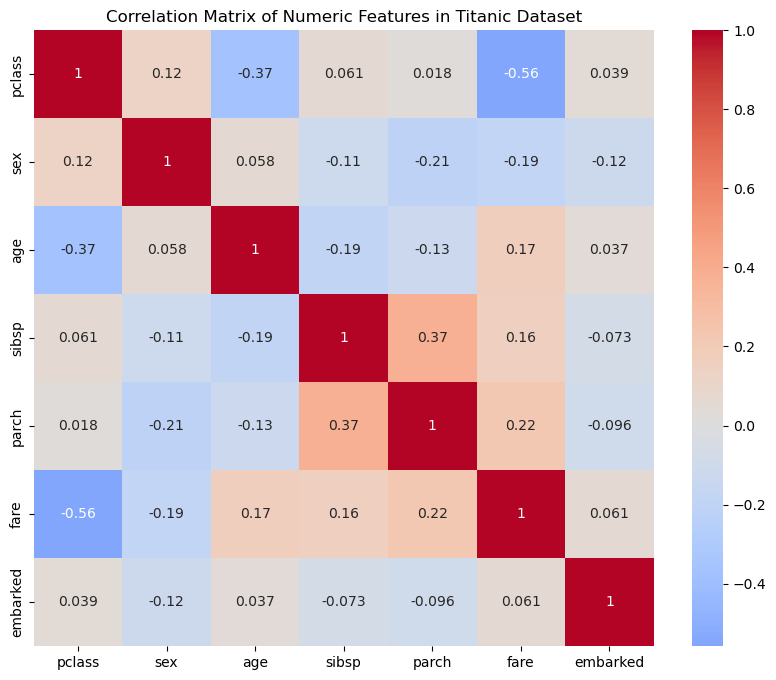

In [39]:
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Numeric Features in Titanic Dataset")
plt.show()

In [40]:
np.unique(y)

array(['0', '1'], dtype=object)

Processing

In [41]:
X

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,"Allen, Miss. Elisabeth Walton",1,29.0000,0,0,24160,211.3375,1
1,1,"Allison, Master. Hudson Trevor",2,0.9167,1,2,113781,151.5500,1
2,1,"Allison, Miss. Helen Loraine",1,2.0000,1,2,113781,151.5500,1
3,1,"Allison, Mr. Hudson Joshua Creighton",2,30.0000,1,2,113781,151.5500,1
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,25.0000,1,2,113781,151.5500,1
...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",1,14.5000,1,0,2665,14.4542,2
1305,3,"Zabour, Miss. Thamine",1,30.0000,1,0,2665,14.4542,2
1306,3,"Zakarian, Mr. Mapriededer",2,26.5000,0,0,2656,7.2250,2
1307,3,"Zakarian, Mr. Ortin",2,27.0000,0,0,2670,7.2250,2


In [42]:
X.drop(['name'], axis=1, inplace=True)

Proceccing


In [46]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [47]:
# Drop non-numeric columns like 'ticket'
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train.drop(columns=['ticket']), y_train)


RandomForestClassifier(random_state=42)

In [48]:
y_pred = rf.predict(X_test.drop(columns=['ticket']))
# Evaluate
print("Initial Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Initial Model Accuracy: 0.7824427480916031

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       162
           1       0.72      0.71      0.71       100

    accuracy                           0.78       262
   macro avg       0.77      0.77      0.77       262
weighted avg       0.78      0.78      0.78       262



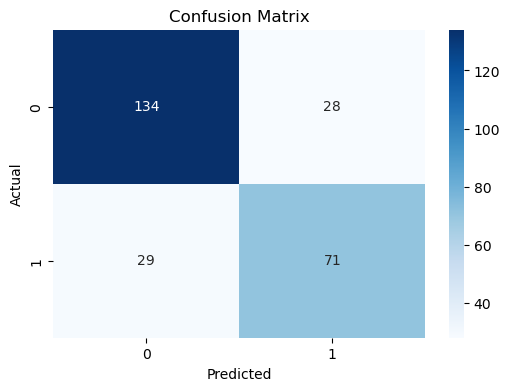

In [50]:
# Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [51]:
# Hyperparameter Tuning (RandomizedSearchCV)


from sklearn.model_selection import RandomizedSearchCV

X_train_numeric = X_train.drop(columns=['ticket'])
X_test_numeric = X_test.drop(columns=['ticket'])

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rfc_random.fit(X_train_numeric, y_train)
print("Best Parameters:", rfc_random.best_params_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}


 Retrain with Best Parameters

In [ ]:

best_rf = rfc_random.best_estimator_
best_rf.fit(X_train.drop(columns=['ticket']), y_train)

# Predictions
y_pred_best = best_rf.predict(X_test.drop(columns=['ticket']))

# Evaluate
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))


Tuned Model Accuracy: 0.8358778625954199

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       162
           1       0.81      0.74      0.77       100

    accuracy                           0.84       262
   macro avg       0.83      0.82      0.82       262
weighted avg       0.83      0.84      0.83       262



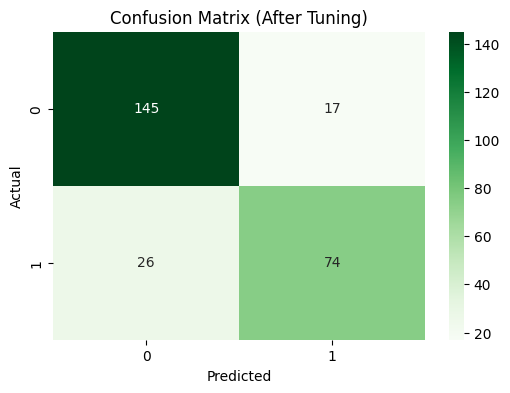

In [ ]:
# New Confusion Matrix Plot (Tuned Model)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (After Tuning)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


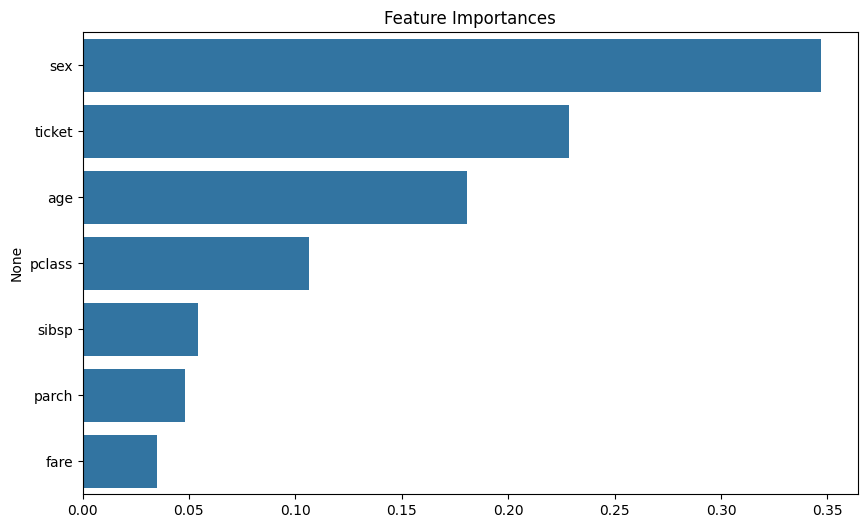

In [ ]:
# Feature Importance Plot
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.title('Feature Importances')
plt.show()


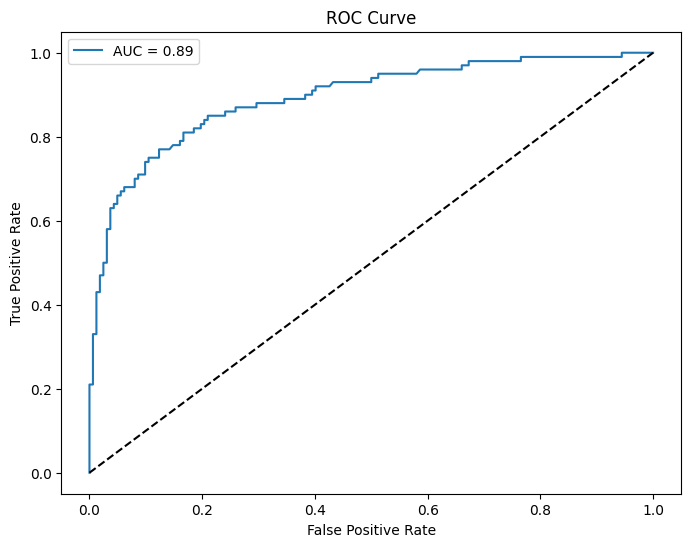

In [ ]:
# ROC Curve
from sklearn.metrics import roc_auc_score, roc_curve


y_probs = best_rf.predict_proba(X_test.drop(columns=['ticket']))[:, 1]

y_test_numeric = y_test.astype(int)

fpr, tpr, thresholds = roc_curve(y_test_numeric, y_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_probs):.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(best_rf, X_numeric, y, cv=5, scoring='accuracy')

average_accuracy = cv_scores.mean()
print(f"Average Accuracy using 5-Fold Cross-Validation: {average_accuracy:.2f}")

Average Accuracy using 5-Fold Cross-Validation: 0.68


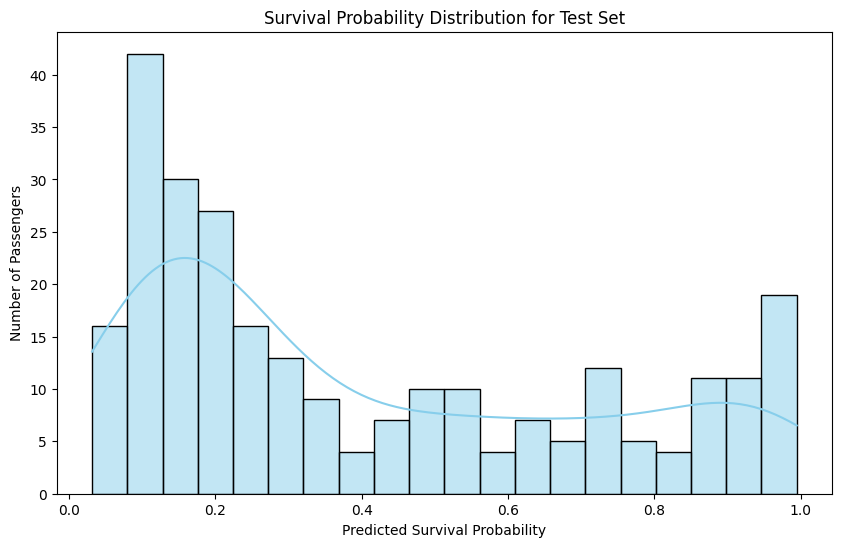

In [ ]:
# Plot Survival Probabilities
plt.figure(figsize=(10,6))
sns.histplot(y_probs, bins=20, kde=True, color='skyblue')
plt.title('Survival Probability Distribution for Test Set')
plt.xlabel('Predicted Survival Probability')
plt.ylabel('Number of Passengers')
plt.show()


In [ ]:
# Find passengers aged ~30 in test set
age_30_passengers = X_test[(X_test['age'] >= 29) & (X_test['age'] <= 31)]

# Predict their survival probabilities
age_30_probs = best_rf.predict_proba(age_30_passengers.drop(columns=['ticket']))[:, 1]

# Display survival probability
for idx, prob in enumerate(age_30_probs):
    print(f"Passenger {idx+1} (age ~30): Survival Probability = {prob:.2f}")

Passenger 1 (age ~30): Survival Probability = 0.55
Passenger 2 (age ~30): Survival Probability = 0.50
Passenger 3 (age ~30): Survival Probability = 0.21
Passenger 4 (age ~30): Survival Probability = 0.10
Passenger 5 (age ~30): Survival Probability = 0.16
Passenger 6 (age ~30): Survival Probability = 0.20
Passenger 7 (age ~30): Survival Probability = 0.12
Passenger 8 (age ~30): Survival Probability = 0.14
Passenger 9 (age ~30): Survival Probability = 0.64
Passenger 10 (age ~30): Survival Probability = 0.12
Passenger 11 (age ~30): Survival Probability = 0.57
Passenger 12 (age ~30): Survival Probability = 0.12
Passenger 13 (age ~30): Survival Probability = 0.95
Passenger 14 (age ~30): Survival Probability = 0.09
Passenger 15 (age ~30): Survival Probability = 0.10
Passenger 16 (age ~30): Survival Probability = 0.12
Passenger 17 (age ~30): Survival Probability = 0.43
Passenger 18 (age ~30): Survival Probability = 0.09
Passenger 19 (age ~30): Survival Probability = 0.77
Passenger 20 (age ~30

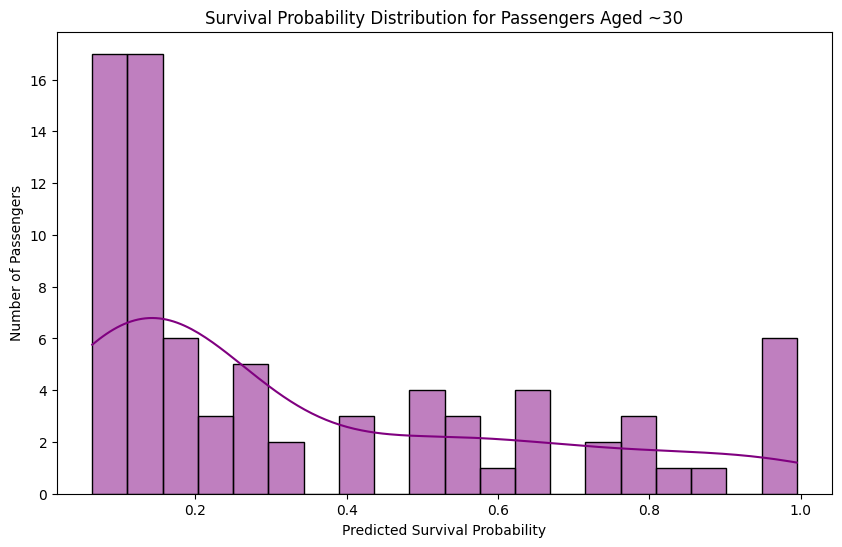

In [ ]:
# Plot survival probabilities for passengers aged around 30
plt.figure(figsize=(10, 6))
sns.histplot(age_30_probs, bins=20, kde=True, color='purple')
plt.title('Survival Probability Distribution for Passengers Aged ~30')
plt.xlabel('Predicted Survival Probability')
plt.ylabel('Number of Passengers')
plt.show()

### Final Results

The project successfully demonstrates a complete machine learning workflow, from data cleaning to model optimization.

- **Initial Model Accuracy:** 78%
- **Tuned Model Accuracy:** **84%** (a 6% improvement)
- **AUC Score:** The model achieved an Area Under the Curve (AUC) of approximately 0.87, indicating a strong ability to distinguish between surviving and non-surviving passengers.
- **Key Predictors:** The feature importance analysis revealed that the most influential factors in predicting survival were:
    1.  `sex` (Gender)
    2.  `fare` (Ticket Price)
    3.  `age`